<a href="https://colab.research.google.com/github/ayaz-ali-36/GB-FloodGuard/blob/main/Diabetes-ModelsComparison/lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pima Indians Diabetes-----------comparing six alogrithms

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold
)

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    f1_score,
    recall_score,
    precision_score,
    accuracy_score
)

from sklearn.dummy import DummyClassifier

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')

print("Libraries Imported")

Libraries Imported


In [5]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'

cols = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Outcome'
]

df = pd.read_csv(url, names=cols)

print(df.shape)

print(df.head())

print(df.describe().round(2))

print(df['Outcome'].value_counts())

(768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.00   
mean          3.85   120.89          69.11          20.54    79.80   31.99   
std           3.37    31.97          19.36          15.95   

In [6]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [7]:
zero_cols = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

for col in zero_cols:

    zeros = (df[col] == 0).sum()

    pct = zeros / len(df) * 100

    print(col, zeros, pct)

Glucose 5 0.6510416666666667
BloodPressure 35 4.557291666666666
SkinThickness 227 29.557291666666668
Insulin 374 48.69791666666667
BMI 11 1.4322916666666665


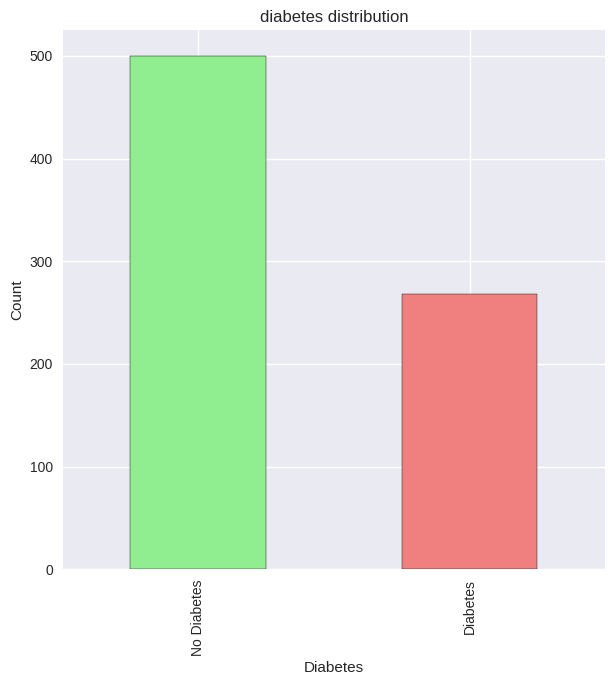

In [8]:
plt.figure(figsize=(7,7))
df['Outcome'].value_counts().plot(kind='bar', color=['lightgreen','lightcoral'] ,edgecolor='black')
plt.title("diabetes distribution")
plt.xticks([0,1],['No Diabetes','Diabetes'])
plt.xlabel('Diabetes')
plt.ylabel('Count')
plt.show()

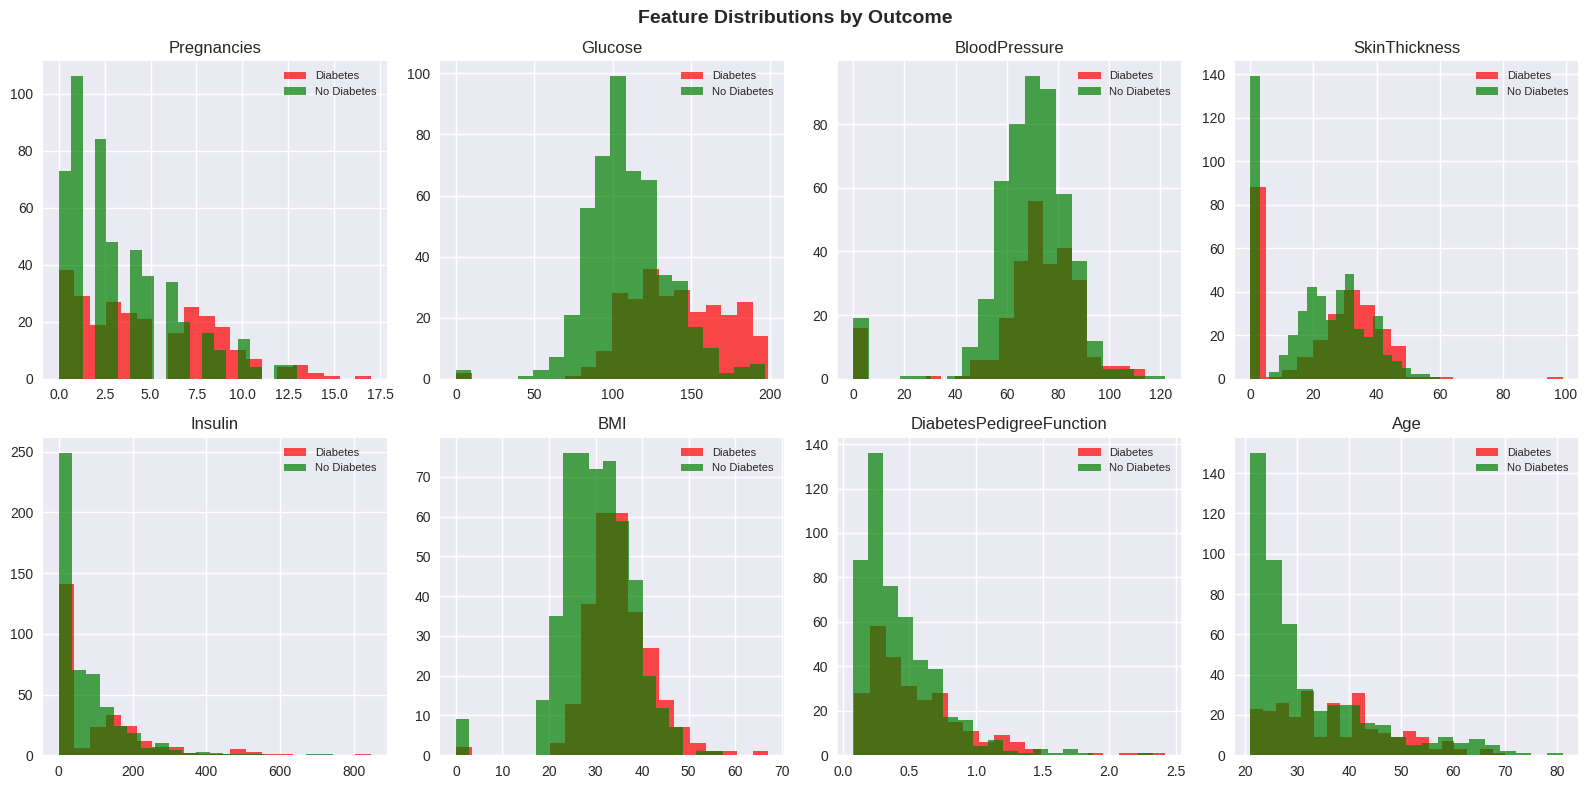

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16,8))

features = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]

for feature, ax in zip(features, axes.flat):

    df[df['Outcome'] == 1][feature].hist(
        ax=ax,
        bins=20,
        alpha=0.7,
        label='Diabetes',
        color='red'
    )

    df[df['Outcome'] == 0][feature].hist(
        ax=ax,
        bins=20,
        alpha=0.7,
        label='No Diabetes',
        color='green'
    )

    ax.set_title(feature)

    ax.legend(fontsize=8)

plt.suptitle(
    'Feature Distributions by Outcome',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

plt.show()





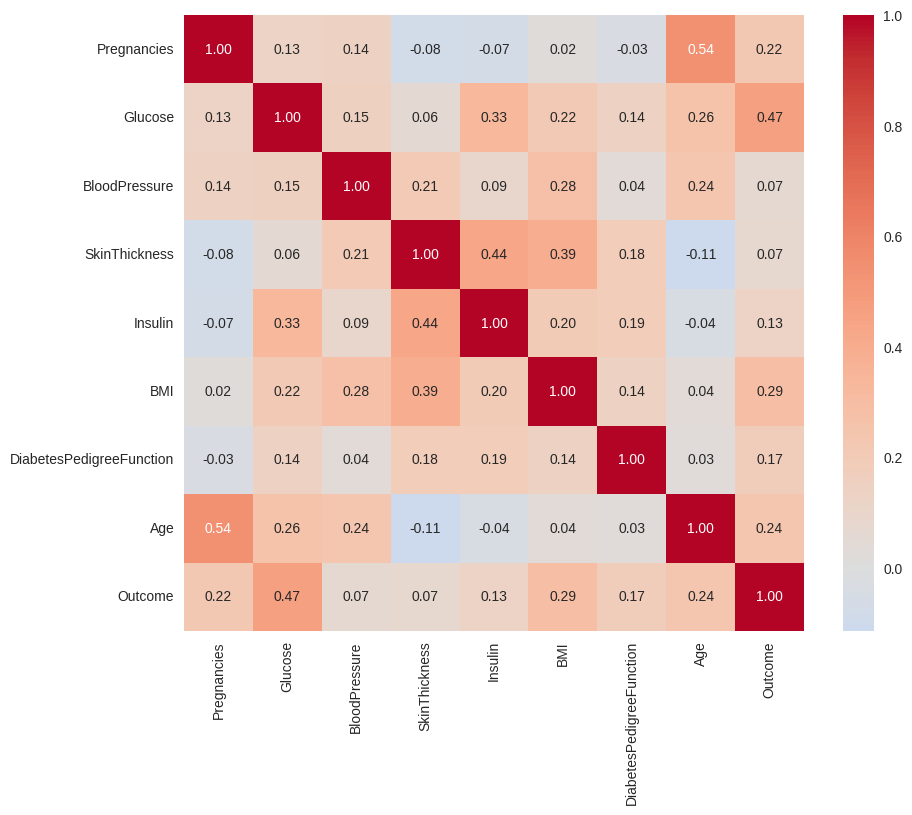

In [10]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.show()

In [11]:
df_clean = df.copy()

for col in zero_cols:

    df_clean[col] = df_clean[col].replace(
        0,
        np.nan
    )
for col in zero_cols:

    median_val = df_clean[col].median()

    df_clean[col] = df_clean[col].fillna(
        median_val
    )


In [12]:
df_clean['BMI_Age'] = (
    df_clean['BMI'] *
    df_clean['Age']
)

df_clean['Glucose_BMI'] = (
    df_clean['Glucose'] *
    df_clean['BMI']
)

df_clean.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Age,Glucose_BMI
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,1680.0,4972.8
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,824.6,2261.0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,745.6,4263.9
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,590.1,2500.9
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,1422.3,5904.7


In [14]:
X = df_clean.drop('Outcome', axis=1)

y = df_clean['Outcome']
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)


In [15]:
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)

X_test_sc = scaler.transform(X_test)

all models

In [16]:


models = {
    'Baseline': {
        'model': DummyClassifier(
            strategy='most_frequent'
        ),
        'scaled': False
    },

    'Logistic Regression': {
        'model': LogisticRegression(
            random_state=42,
            max_iter=1000,
            C=1.0
        ),
        'scaled': True
    },

    'Decision Tree': {
        'model': DecisionTreeClassifier(
            max_depth=5,
            min_samples_leaf=5,
            random_state=42
        ),
        'scaled': False
    },

    'Random Forest': {
        'model': RandomForestClassifier(
            n_estimators=200,
            max_features='sqrt',
            oob_score=True,
            random_state=42,
            n_jobs=-1
        ),
        'scaled': False
    },

    'XGBoost': {
        'model': XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric='logloss'
        ),
        'scaled': False
    },

    'SVM': {
        'model': SVC(
            kernel='rbf',
            C=1.0,
            gamma='scale',
            probability=True,
            random_state=42
        ),
        'scaled': True
    },

    'KNN': {
        'model': KNeighborsClassifier(
            n_neighbors=5,
            metric='euclidean'
        ),
        'scaled': True
    },

    'Naive Bayes': {
        'model': GaussianNB(),
        'scaled': False
    }
}

print(f"Models defined: {len(models)}")

for name in models:
    print(f"  → {name}")

Models defined: 8
  → Baseline
  → Logistic Regression
  → Decision Tree
  → Random Forest
  → XGBoost
  → SVM
  → KNN
  → Naive Bayes


In [25]:
results = []

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, config in models.items():

    model = config['model']

    scaled = config['scaled']

    X_tr = X_train_sc if scaled else X_train

    X_te = X_test_sc if scaled else X_test

    model.fit(X_tr, y_train)

    y_pred = model.predict(X_te)

    y_prob = (
        model.predict_proba(X_te)[:, 1]
        if hasattr(model, 'predict_proba')
        else None
    )

    acc = accuracy_score(y_test, y_pred)

    prec = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    rec = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    auc_score = (
        auc(*roc_curve(y_test, y_prob)[:2])
        if y_prob is not None
        else 0
    )

    cv_f1 = cross_val_score(
        model,
        X_tr,
        y_train,
        cv=cv,
        scoring='f1'
    )

    cv_mean = cv_f1.mean()

    cv_std = cv_f1.std()

    results.append({

        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'AUC': auc_score,
        'CV_F1_Mean': cv_mean,
        'CV_F1_Std': cv_std

    })

    print(f"\n{name}:")

    print(f"  Accuracy: {acc:.3f}")

    print(f"  Recall: {rec:.3f}")

    print(f"  F1: {f1:.3f}")

    print(f"  CV F1: {cv_mean:.3f} ± {cv_std:.3f}")


Baseline:
  Accuracy: 0.649
  Recall: 0.000
  F1: 0.000
  CV F1: 0.000 ± 0.000

Logistic Regression:
  Accuracy: 0.701
  Recall: 0.500
  F1: 0.540
  CV F1: 0.653 ± 0.027

Decision Tree:
  Accuracy: 0.695
  Recall: 0.389
  F1: 0.472
  CV F1: 0.593 ± 0.052

Random Forest:
  Accuracy: 0.753
  Recall: 0.574
  F1: 0.620
  CV F1: 0.612 ± 0.037

XGBoost:
  Accuracy: 0.740
  Recall: 0.630
  F1: 0.630
  CV F1: 0.600 ± 0.034

SVM:
  Accuracy: 0.734
  Recall: 0.519
  F1: 0.577
  CV F1: 0.639 ± 0.017

KNN:
  Accuracy: 0.714
  Recall: 0.574
  F1: 0.585
  CV F1: 0.617 ± 0.052

Naive Bayes:
  Accuracy: 0.727
  Recall: 0.648
  F1: 0.625
  CV F1: 0.642 ± 0.021


              Model  Accuracy   Recall       F1      AUC  CV_F1_Mean  CV_F1_Std
Logistic Regression  0.701299 0.500000 0.540000 0.813148    0.652947   0.026577
        Naive Bayes  0.727273 0.648148 0.625000 0.775370    0.641718   0.021457
                SVM  0.733766 0.518519 0.577320 0.797407    0.639048   0.016656
                KNN  0.714286 0.574074 0.584906 0.769074    0.617074   0.052205
      Random Forest  0.753247 0.574074 0.620000 0.824167    0.612299   0.037068
            XGBoost  0.740260 0.629630 0.629630 0.822593    0.599969   0.034471
      Decision Tree  0.694805 0.388889 0.471910 0.733796    0.593153   0.051811
           Baseline  0.649351 0.000000 0.000000 0.500000    0.000000   0.000000


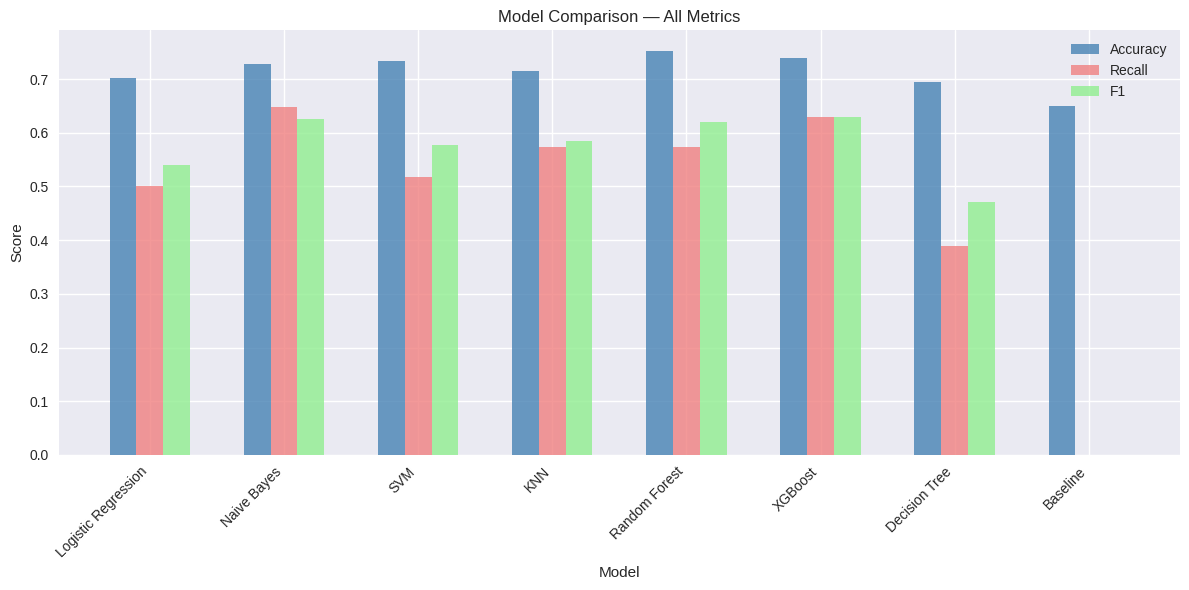

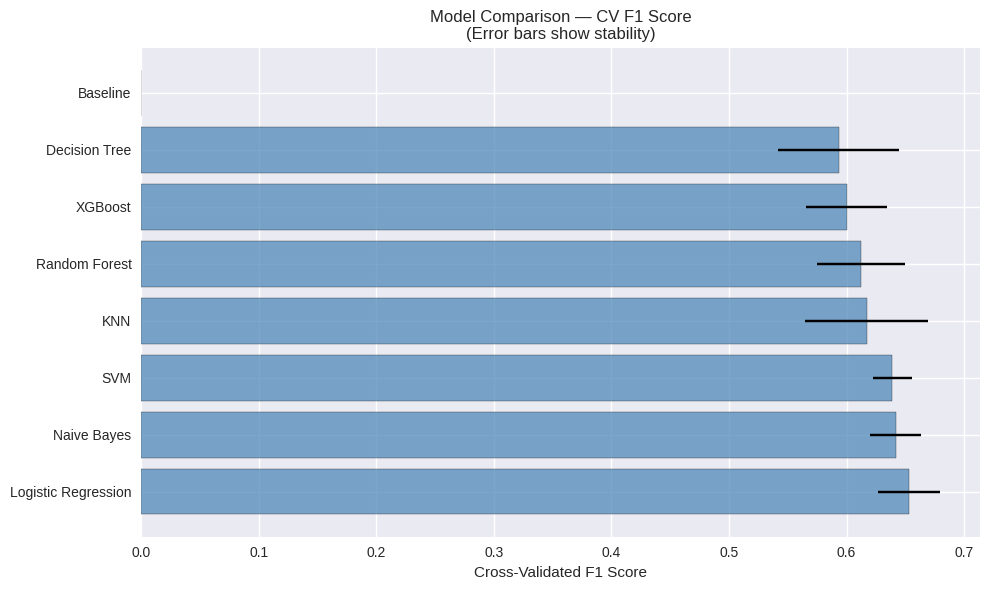

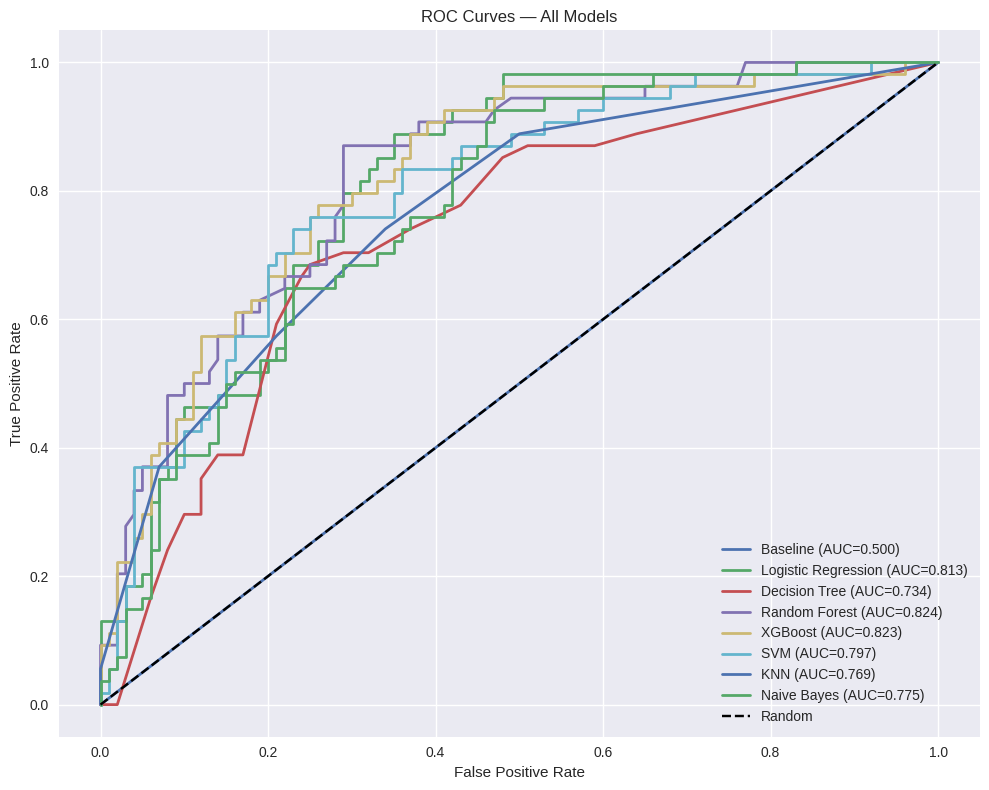

In [26]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    'CV_F1_Mean',
    ascending=False
)

print(
    results_df[
        [
            'Model',
            'Accuracy',
            'Recall',
            'F1',
            'AUC',
            'CV_F1_Mean',
            'CV_F1_Std'
        ]
    ].to_string(index=False)
)

plt.figure(figsize=(12, 6))

x = np.arange(len(results_df))

width = 0.2

plt.bar(
    x - width,
    results_df['Accuracy'],
    width,
    label='Accuracy',
    alpha=0.8,
    color='steelblue'
)

plt.bar(
    x,
    results_df['Recall'],
    width,
    label='Recall',
    alpha=0.8,
    color='lightcoral'
)

plt.bar(
    x + width,
    results_df['F1'],
    width,
    label='F1',
    alpha=0.8,
    color='lightgreen'
)

plt.xlabel('Model')

plt.ylabel('Score')

plt.title('Model Comparison — All Metrics')

plt.xticks(
    x,
    results_df['Model'],
    rotation=45,
    ha='right'
)

plt.legend()

plt.tight_layout()

plt.show()

plt.figure(figsize=(10, 6))

plt.barh(
    results_df['Model'],
    results_df['CV_F1_Mean'],
    xerr=results_df['CV_F1_Std'],
    color='steelblue',
    alpha=0.7,
    edgecolor='black',
    capsize=5
)

plt.xlabel('Cross-Validated F1 Score')

plt.title(
    'Model Comparison — CV F1 Score\n'
    '(Error bars show stability)'
)

plt.tight_layout()

plt.show()

plt.figure(figsize=(10, 8))

for name, config in models.items():

    model = config['model']

    scaled = config['scaled']

    X_te = X_test_sc if scaled else X_test

    if hasattr(model, 'predict_proba'):

        y_prob = model.predict_proba(X_te)[:, 1]

        fpr, tpr, _ = roc_curve(y_test, y_prob)

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f'{name} (AUC={roc_auc:.3f})'
        )

plt.plot(
    [0, 1],
    [0, 1],
    'k--',
    label='Random'
)

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('ROC Curves — All Models')

plt.legend(loc='lower right')

plt.tight_layout()

plt.show()

In [27]:
winner = results_df.iloc[0]

print(f"\nWINNER: {winner['Model']}")

print(
    f"CV F1: "
    f"{winner['CV_F1_Mean']:.3f} "
    f"± {winner['CV_F1_Std']:.3f}"
)

print(
    f"Accuracy: "
    f"{winner['Accuracy']:.3f}"
)

print(
    f"Recall: "
    f"{winner['Recall']:.3f}"
)

print(
    f"AUC: "
    f"{winner['AUC']:.3f}"
)

baseline_f1 = results_df[
    results_df['Model'] == 'Baseline'
]['F1'].values[0]

improvement = (
    winner['CV_F1_Mean']
    - baseline_f1
)

print(
    f"\nImprovement over baseline: "
    f"{improvement:.3f}"
)


WINNER: Logistic Regression
CV F1: 0.653 ± 0.027
Accuracy: 0.701
Recall: 0.500
AUC: 0.813

Improvement over baseline: 0.653
